# Model Comparison: ARIMA vs Random Forest vs LSTM

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Note on currency:** `ARIMA_model_ALL.ipynb` evaluates each bank in its native currency (Lloyds/Barclays: GBX pence, Goldman Sachs: **USD**), because ARIMA is fitted separately per bank and currency scale doesn't affect its accuracy. `Random_Forest_model.ipynb` and `LSTM_model.ipynb` pool all three banks into one model, so they evaluate every bank — including Goldman Sachs — in **GBX-standardised** pence.

This means **Goldman Sachs' MAE/RMSE are not directly comparable across models** here: ARIMA's figure is in USD, Random Forest/LSTM's is in GBX. Lloyds and Barclays don't have this problem (all three models use native GBX pence for them). This notebook makes the mismatch explicit rather than silently comparing mismatched units, and relies on **MAPE** (scale-free, unaffected by currency) for the primary cross-model comparison — the same approach your report already uses for cross-bank ARIMA comparison (Section 4.2).

## Load Results

Run `ARIMA_model_ALL.ipynb`, `Random_Forest_model.ipynb`, and `LSTM_model.ipynb` first — each saves its own results CSV, loaded here.

In [2]:
arima = pd.read_csv('/content/arima_results_summary.csv')
rf = pd.read_csv('/content/random_forest_results_summary.csv')
lstm = pd.read_csv('/content/lstm_results_summary.csv')

arima['Model'] = 'ARIMA'
print('ARIMA:'); display(arima)
print('Random Forest:'); display(rf)
print('LSTM:'); display(lstm)


ARIMA:


,Bank,Model,AIC,Diverged_Steps,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,Lloyds,ARIMA,6634.024184,0,2060.441727,0.971179,1.364817,1.221300,0.995127
1,Barclays,ARIMA,12599.331427,0,77.562391,5.039426,6.871115,1.468221,0.995156
2,Goldman Sachs,ARIMA,13042.557679,0,1218.839367,9.872191,14.576095,1.387950,0.994712


Random Forest:


,Bank,Model,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,All (pooled),Random Forest,1079.724944,257.528650,651.218386,1.946695,0.999375
1,Goldman Sachs,Random Forest,NaN,770.117711,1131.466136,1.438522,0.993674
2,Lloyds,Random Forest,NaN,2.144875,2.432576,2.894724,0.984500
3,Barclays,Random Forest,NaN,5.124606,7.035315,1.500895,0.994904


LSTM:


,Bank,Model,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,All (pooled),LSTM,2424.692313,1127.764382,2529.506006,3.626602,0.990541
1,Barclays,LSTM,NaN,12.862414,16.892997,3.310844,0.970723
2,Goldman Sachs,LSTM,NaN,3380.274866,4388.669831,5.665277,0.905477
3,Lloyds,LSTM,NaN,1.628753,2.188866,1.914068,0.987467


## Combine Into One Table

ARIMA has no `"All (pooled)"` row (each bank is a genuinely separate model, there's nothing to pool), so one is added here by averaging across its three banks, purely so all three models have a directly comparable summary row. `Training_Time_Sec` is summed across banks for ARIMA (three separate models really were fitted) and averaged for the error metrics.

In [3]:
arima_pooled = pd.DataFrame([{
    'Bank': 'All (mean of 3 banks)',
    'Model': 'ARIMA',
    'Training_Time_Sec': arima['Training_Time_Sec'].sum(),
    'MAE': arima['MAE'].mean(),
    'RMSE': arima['RMSE'].mean(),
    'MAPE': arima['MAPE'].mean(),
    'R2': arima['R2'].mean(),
}])

arima_full = pd.concat([arima_pooled, arima[['Bank', 'Model', 'Training_Time_Sec', 'MAE', 'RMSE', 'MAPE', 'R2']]], ignore_index=True)

all_results = pd.concat([arima_full, rf, lstm], ignore_index=True)
all_results


,Bank,Model,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,All (mean of 3 banks),ARIMA,3356.843485,5.294265,7.604009,1.359157,0.994999
1,Lloyds,ARIMA,2060.441727,0.971179,1.364817,1.221300,0.995127
2,Barclays,ARIMA,77.562391,5.039426,6.871115,1.468221,0.995156
3,Goldman Sachs,ARIMA,1218.839367,9.872191,14.576095,1.387950,0.994712
4,All (pooled),Random Forest,1079.724944,257.528650,651.218386,1.946695,0.999375
5,Goldman Sachs,Random Forest,NaN,770.117711,1131.466136,1.438522,0.993674
6,Lloyds,Random Forest,NaN,2.144875,2.432576,2.894724,0.984500
7,Barclays,Random Forest,NaN,5.124606,7.035315,1.500895,0.994904
8,All (pooled),LSTM,2424.692313,1127.764382,2529.506006,3.626602,0.990541
9,Barclays,LSTM,NaN,12.862414,16.892997,3.310844,0.970723


## Overall Comparison (Table 8 style)

In [4]:
overview = all_results[all_results['Bank'].str.startswith('All')].reset_index(drop=True)
overview


,Bank,Model,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,All (mean of 3 banks),ARIMA,3356.843485,5.294265,7.604009,1.359157,0.994999
1,All (pooled),Random Forest,1079.724944,257.528650,651.218386,1.946695,0.999375
2,All (pooled),LSTM,2424.692313,1127.764382,2529.506006,3.626602,0.990541


### MAPE and R² — safe to compare directly (scale-free)

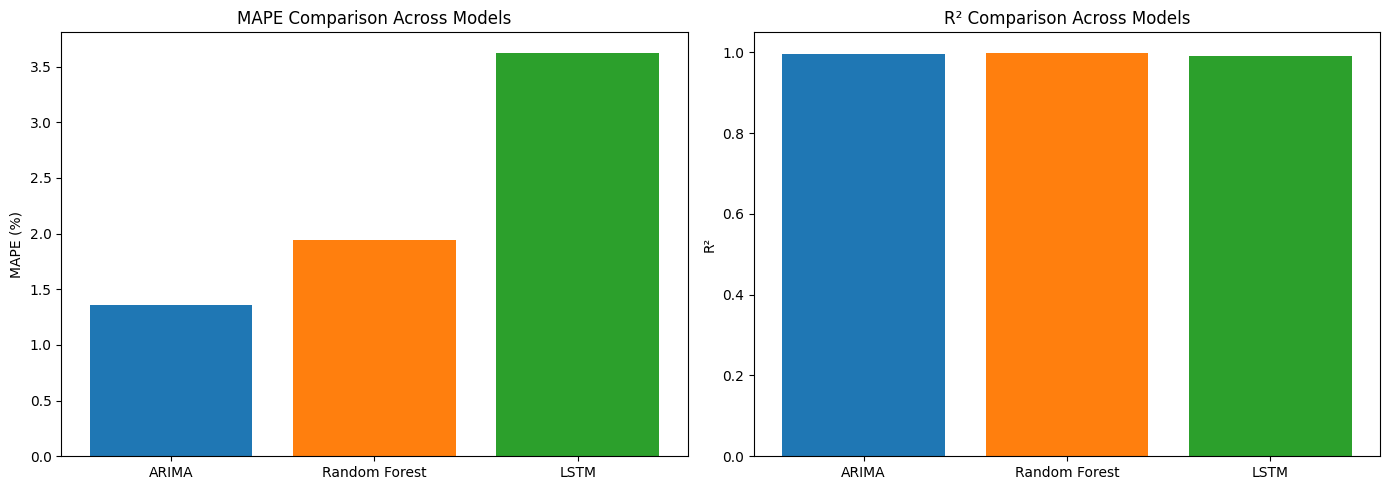

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(overview['Model'], overview['MAPE'], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[0].set_title('MAPE Comparison Across Models')
axes[0].set_ylabel('MAPE (%)')

axes[1].bar(overview['Model'], overview['R2'], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_title('R² Comparison Across Models')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()


### MAE and RMSE — caution: mixed currency for Goldman Sachs

These are shown for completeness (matching the report's Figures 18–19) but the "All" rows blend GBX (Lloyds, Barclays, and Random Forest/LSTM's Goldman Sachs) with ARIMA's native-USD Goldman Sachs figure. Treat as directionally indicative, not precise — MAPE above is the trustworthy comparison.

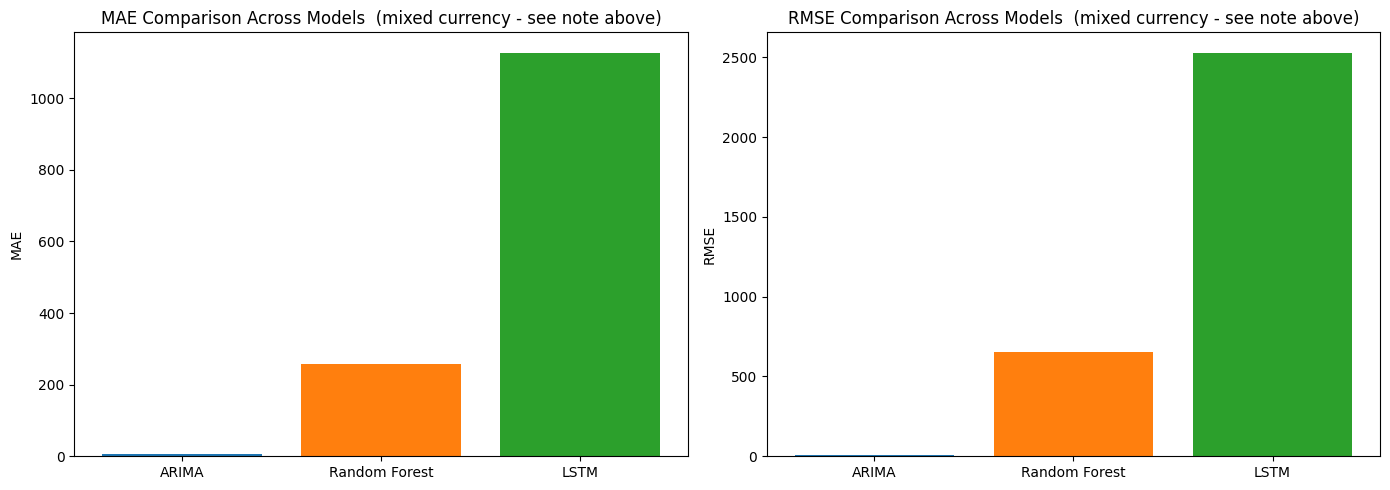

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(overview['Model'], overview['MAE'], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[0].set_title('MAE Comparison Across Models  (mixed currency - see note above)')
axes[0].set_ylabel('MAE')

axes[1].bar(overview['Model'], overview['RMSE'], color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_title('RMSE Comparison Across Models  (mixed currency - see note above)')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()


### Training Time

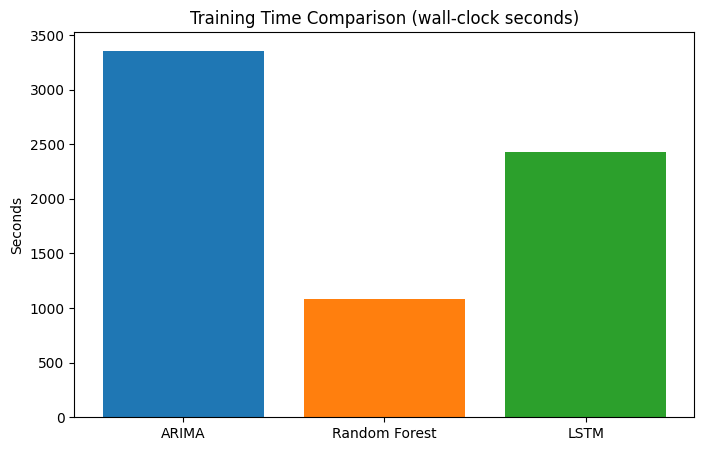

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(overview['Model'], overview['Training_Time_Sec'], color=['tab:blue', 'tab:orange', 'tab:green'])
plt.title('Training Time Comparison (wall-clock seconds)')
plt.ylabel('Seconds')
plt.show()


## Per-Bank Comparison

All three models now report per-bank metrics, so each bank can be compared fairly across models — Lloyds and Barclays are apples-to-apples (all three models use native/GBX pence for them); Goldman Sachs' MAE/RMSE differ in unit (ARIMA=USD, RF/LSTM=GBX) but MAPE and R² remain safe to compare.

In [8]:
per_bank = all_results[~all_results['Bank'].str.startswith('All')].copy()
per_bank_pivot_mape = per_bank.pivot(index='Bank', columns='Model', values='MAPE')
per_bank_pivot_r2 = per_bank.pivot(index='Bank', columns='Model', values='R2')

print('MAPE by bank and model:')
display(per_bank_pivot_mape)
print('\nR² by bank and model:')
display(per_bank_pivot_r2)


MAPE by bank and model:


Model,ARIMA,LSTM,Random Forest
Bank,,,
Barclays,1.468221,3.310844,1.500895
Goldman Sachs,1.387950,5.665277,1.438522
Lloyds,1.221300,1.914068,2.894724



R² by bank and model:


Model,ARIMA,LSTM,Random Forest
Bank,,,
Barclays,0.995156,0.970723,0.994904
Goldman Sachs,0.994712,0.905477,0.993674
Lloyds,0.995127,0.987467,0.984500


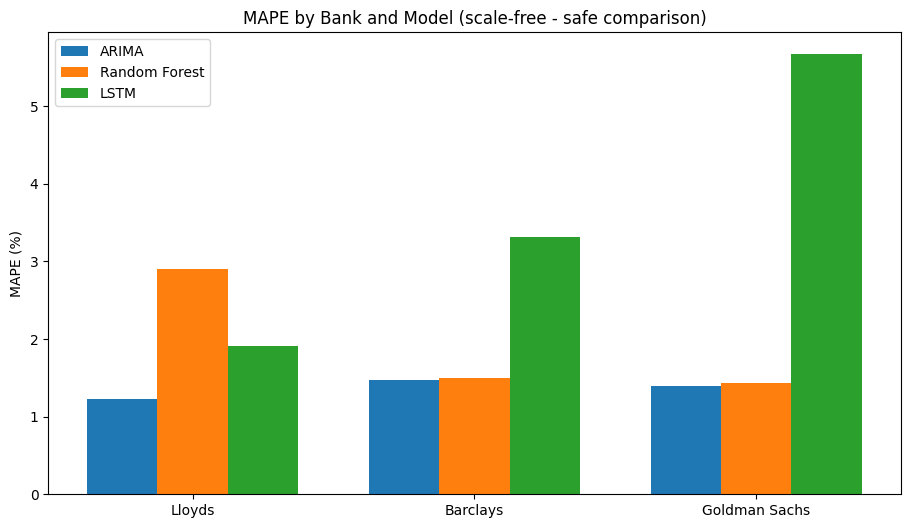

In [9]:
banks = per_bank['Bank'].unique()
models = per_bank['Model'].unique()
x = np.arange(len(banks))
width = 0.25

plt.figure(figsize=(11, 6))
for i, model in enumerate(models):
    values = [per_bank[(per_bank['Bank'] == b) & (per_bank['Model'] == model)]['MAPE'].values[0] for b in banks]
    plt.bar(x + i * width, values, width, label=model)

plt.xticks(x + width, banks)
plt.ylabel('MAPE (%)')
plt.title('MAPE by Bank and Model (scale-free - safe comparison)')
plt.legend()
plt.show()


### Comparison Heatmap (MAPE and R² only, by bank and model)

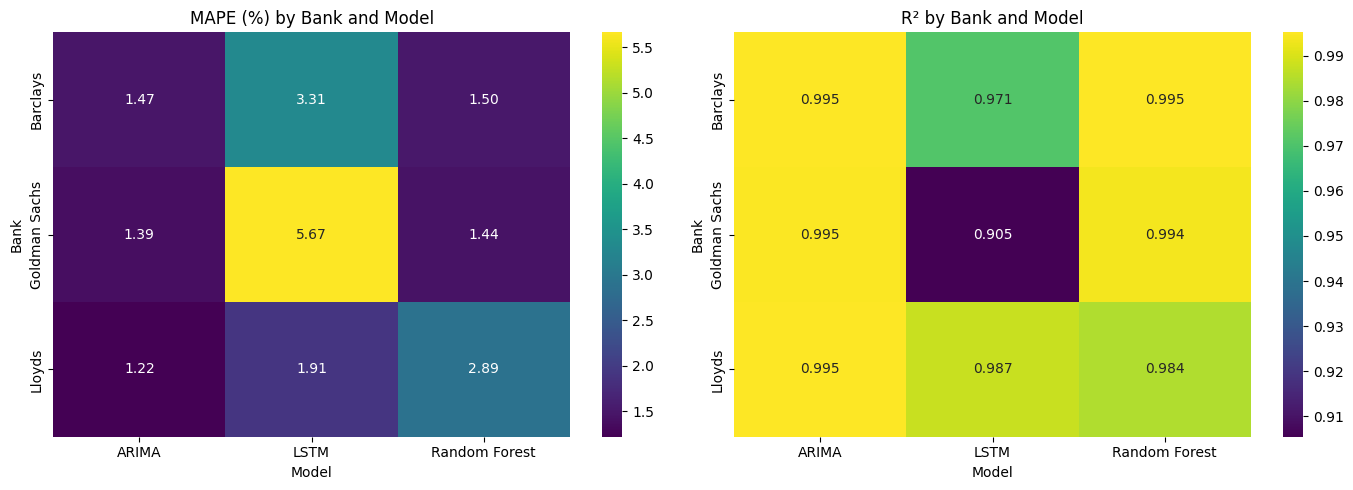

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(per_bank_pivot_mape, annot=True, cmap='viridis', fmt='.2f', ax=axes[0])
axes[0].set_title('MAPE (%) by Bank and Model')

sns.heatmap(per_bank_pivot_r2, annot=True, cmap='viridis', fmt='.3f', ax=axes[1])
axes[1].set_title('R² by Bank and Model')

plt.tight_layout()
plt.show()


## Save Combined Results

In [11]:
all_results.to_csv('model_comparison_summary.csv', index=False)
print('Saved model_comparison_summary.csv')
all_results


Saved model_comparison_summary.csv


,Bank,Model,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,All (mean of 3 banks),ARIMA,3356.843485,5.294265,7.604009,1.359157,0.994999
1,Lloyds,ARIMA,2060.441727,0.971179,1.364817,1.221300,0.995127
2,Barclays,ARIMA,77.562391,5.039426,6.871115,1.468221,0.995156
3,Goldman Sachs,ARIMA,1218.839367,9.872191,14.576095,1.387950,0.994712
4,All (pooled),Random Forest,1079.724944,257.528650,651.218386,1.946695,0.999375
5,Goldman Sachs,Random Forest,NaN,770.117711,1131.466136,1.438522,0.993674
6,Lloyds,Random Forest,NaN,2.144875,2.432576,2.894724,0.984500
7,Barclays,Random Forest,NaN,5.124606,7.035315,1.500895,0.994904
8,All (pooled),LSTM,2424.692313,1127.764382,2529.506006,3.626602,0.990541
9,Barclays,LSTM,NaN,12.862414,16.892997,3.310844,0.970723
